In [ ]:
# XPLAIN import 
from xplain.attribution.model import ReferenceTransformer, XSDefaultEncoder
from xplain.attribution.util import plot_attributions
# other imports
from datasets import load_dataset
from sentence_transformers.models import Pooling
import torch
import random
from pprint import pprint

### Model initialization

In [ ]:
# SBERT model
model_name = 'sentence-transformers/msmarco-MiniLM-L12-cos-v5'
transformer = ReferenceTransformer(model_name)
pooling = Pooling(transformer.get_word_embedding_dimension())
model = XSDefaultEncoder(modules=[transformer, pooling])
device = torch.device('cuda:4')
model.to(device)

### Loading dataset

In [5]:
ds = load_dataset("microsoft/ms_marco", "v1.1")

### Sampling query and passage

In [19]:
split = 'test'
# idx = 0
idx = random.randint(0, len(ds[split]) - 1)
inst = ds[split][idx]
query = inst['query']
passage_idx = random.randint(0, len(inst['passages']) - 1)
passage_label = inst['passages']['is_selected'][passage_idx]
passage = inst['passages']['passage_text'][passage_idx]

pprint(f"Query:\n{query}")
pprint(f"Passage:\n{passage}")
pprint(f"Passage Label: {passage_label}")

'Query:\nhow early to get to airport'
('Passage:\n'
 'All air travelers must arrive at the airport well in advance of their '
 "international flights. They'll need time to check baggage and might need to "
 "check in for the flight. Each airport's wait times at the check-in counter, "
 'baggage check and TSA checkpoint vary, which affects the recommended arrival '
 'time. International airports, such as the Orlando International Airport, '
 'suggest arriving three hours before flight departure for international '
 'travel.')
'Passage Label: 1'


### Attribution computation

In [20]:
model.reset_attribution()
model.init_attribution_to_layer(idx=10, N_steps=10)
A, tokens_a, tokens_b = model.explain_similarity(
    query, 
    passage, 
    move_to_cpu=False,
    device=device
)

  0%|          | 0/384 [00:00<?, ?it/s]

100%|██████████| 384/384 [00:00<00:00, 628.57it/s]


### Attribution visualization

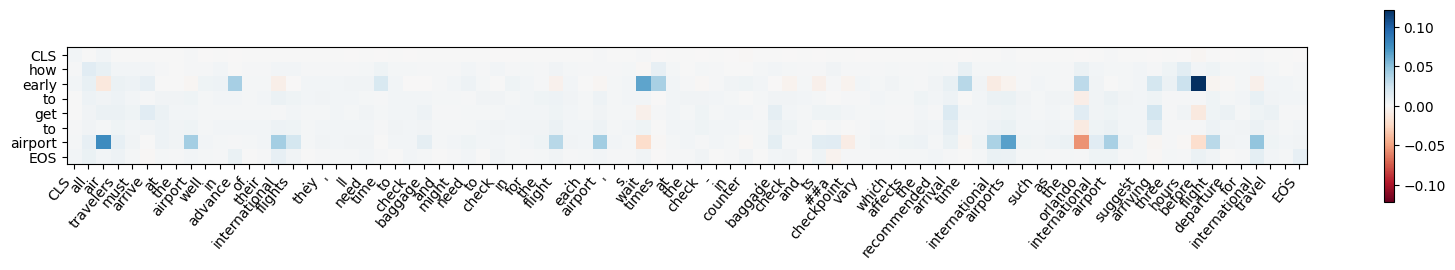

In [21]:
f = plot_attributions(
    A, 
    tokens_a, 
    tokens_b, 
    size=(20, 5), 
    range=None, 
    show_colorbar=True, 
    shrink_colorbar=.5,
)
f.show()